In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import KFold, StratifiedKFold
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Modelo de GPU: {torch.cuda.get_device_name(0)}")

GPU disponible: True
Modelo de GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:

PROJECT_ROOT = Path(os.getcwd()).parent

print(PROJECT_ROOT)


ETIQUETADO_PATH = PROJECT_ROOT / "data" / "limpieza_final" / "etiquetado_humano_unificado.csv"

print(ETIQUETADO_PATH)

corpus = pd.read_csv(ETIQUETADO_PATH, encoding = 'utf-8-sig')

print(ETIQUETADO_PATH)
print(corpus.head())

c:\Users\nicte\Documents\LLM_PROJECT_1
c:\Users\nicte\Documents\LLM_PROJECT_1\data\limpieza_final\etiquetado_humano_unificado.csv
c:\Users\nicte\Documents\LLM_PROJECT_1\data\limpieza_final\etiquetado_humano_unificado.csv
                                          comentario  etiquetado_humano  \
0  cuál es el más cercado para rayar el nombre de...                3.0   
1  esos baños deberian estar en el metro no saben...                2.0   
2                           no pues bueno me da risa                3.0   
3                                los van a abandonar                2.0   
4                           nada los tiene contentos                4.0   

         categoria  
0  infraestructura  
1  infraestructura  
2  infraestructura  
3  infraestructura  
4  infraestructura  


In [4]:
analizador = pipeline(
    "sentiment-analysis",
#    model = 'citizenlab/distilbert-base-multilingual-cased-toxicity' #podria funcionar con un tuneo
#    model ="BAAI/bge-reranker-v2-m3" #no sirve para el objetivo
#    model = openai-community/gpt2 #no compro ni por barato
#    model="distilbert-base-uncased-finetuned-sst-2-english" #el que usa el profe. podria funcionar tuneado
    model = 'nlptown/bert-base-multilingual-uncased-sentiment', #podria funcionar con un tuneo, el mas prometedor por ahora    
#    model = "FacebookAI/roberta-large-mnli", #puede prometer
#    model = 'FacebookAI/xlm-roberta-large', #demasiado crudo
#    model = 'cardiffnlp/twitter-roberta-base-sentiment-latest', #podria ser, pero hay que enseñarle español
#    model = 'Bhumika/roberta-base-finetuned-sst2',
    torch_dtype="auto",           # Detecta automáticamente el tipo óptimo
#    device_map="auto"             # Coloca el modelo en GPU si está disponible
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [5]:
etiqueta = []
confianza = []

for texto in list(corpus['comentario']):
    try:
        aux = analizador(texto)[0]
        etiqueta.append(aux['label'])
        confianza.append(aux['score'])
    except:
        print(texto, type(texto))

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Vamos ahora con el calculo de las metricas del baseline

In [7]:
resultados = pd.DataFrame({'Comentario':list(corpus['comentario']),'Puntuacion Estimada': [float(etiq[0]) for etiq in etiqueta],
                           'Puntuacion Real':corpus['etiquetado_humano'],'Confianza':confianza})

print(resultados)
#resultados.to_csv('C:/Users/inqui/OneDrive/Desktop/borrar.csv')
print('--------------------------------------------------------------------')
#print(resultados.dropna())


#aqui se hace la comparacion promedio de atinados y predichos, matriz de confusion, etc...


                                             Comentario  Puntuacion Estimada  \
0     cuál es el más cercado para rayar el nombre de...                  5.0   
1     esos baños deberian estar en el metro no saben...                  1.0   
2                              no pues bueno me da risa                  2.0   
3                                   los van a abandonar                  1.0   
4                              nada los tiene contentos                  1.0   
...                                                 ...                  ...   
2573                                          no mañana                  1.0   
2574                               wwow viva mexicooooo                  5.0   
2575  como esperas turista así como tienes el país t...                  1.0   
2576  un pais con esos niveles de delincuencia e ins...                  1.0   
2577  que dice que salgamos a las calles a disfrutar...                  5.0   

      Puntuacion Real  Confianza  
0   

                       precision    recall  f1-score   support

             negativa       0.41      0.66      0.51       173
parcialmente negativa       0.38      0.11      0.17       159
              neutral       0.33      0.12      0.18       204
parcialmente positiva       0.12      0.13      0.13        30
             positiva       0.05      0.47      0.08        15

             accuracy                           0.29       581
            macro avg       0.26      0.30      0.21       581
         weighted avg       0.35      0.29      0.27       581

Balanced accuracy: 0.29768535923476164


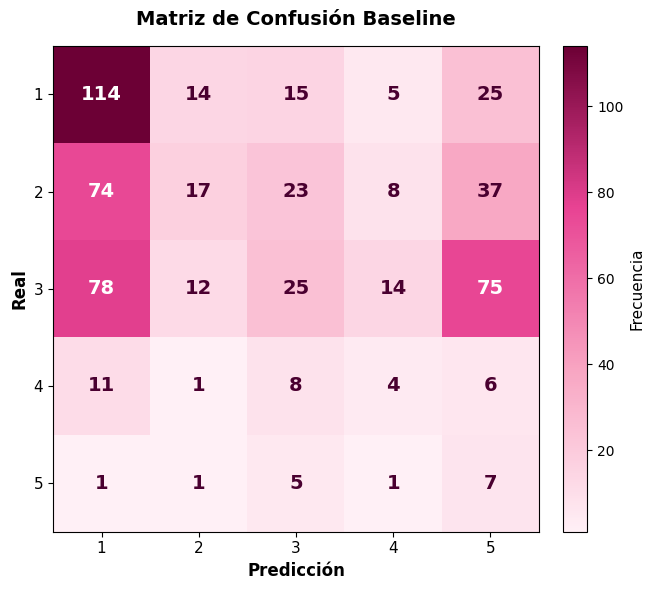

In [8]:
muestra = resultados[np.isnan(corpus["etiquetado_humano"]) == False]

orden = [1, 2, 3, 4, 5]
nombres = [
    "negativa",
    "parcialmente negativa",
    "neutral",
    "parcialmente positiva",
    "positiva"
]

print(
    classification_report(
        muestra["Puntuacion Real"],
        muestra["Puntuacion Estimada"],
        labels=orden,
        target_names=nombres
    )
)

print(
    "Balanced accuracy:",
    balanced_accuracy_score(
        muestra["Puntuacion Real"],
        muestra["Puntuacion Estimada"]
    )
)

cm = confusion_matrix(
    muestra["Puntuacion Real"],
    muestra["Puntuacion Estimada"],
    labels=orden
)

cmap_rositas = LinearSegmentedColormap.from_list(
    "rositas",
    ["#fff0f6", "#f8a5c2", "#e84393", "#6c0035"]
)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap=cmap_rositas)

ax.set_xticks(range(len(orden)))
ax.set_xticklabels(orden, fontsize=11)

ax.set_yticks(range(len(orden)))
ax.set_yticklabels(orden, fontsize=11)

ax.set_xlabel("Predicción", fontsize=12, fontweight="bold")
ax.set_ylabel("Real", fontsize=12, fontweight="bold")
ax.set_title(
    "Matriz de Confusión Baseline",
    fontsize=14,
    fontweight="bold",
    pad=15
)

for i in range(len(orden)):
    for j in range(len(orden)):
        valor = cm[i, j]
        ax.text(
            j, i, str(valor),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="white" if valor > cm.max() / 2 else "#4a0030"
        )

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Frecuencia", fontsize=11)

ax.grid(False)
plt.tight_layout()
plt.show()